In [3]:
import xarray as xr
import glob
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(str(Path("../src").resolve()))
from radar_lwc.preprocessing.chirps import combine_chirps
from radar_lwc.preprocessing.get_reflectivity import get_reflectivity
from radar_lwc.preprocessing.clean import drop_duplicate_times

BUILT PATH AND OPEN DATASETS

In [4]:
base_path_w = Path("../data/raw/cmtrace/20230928")
base_path_ka = Path("../data/raw/cmtrace/20230928_KaBand")

In [5]:
zen_files = sorted(glob.glob(str(base_path_w / "*ZEN.LV1.nc")))
ds_zen = xr.open_mfdataset(zen_files)

EPOCH IS CREATED AND TIME COORDS IS SET TO "epoch" + the values are added as delta t with "epoch + pd.to_timedelta(ds_zen["Time"].values"

In [5]:
epoch = pd.Timestamp("2001-01-01 00:00:00")
ds_zen = ds_zen.assign_coords(Time=epoch + pd.to_timedelta(ds_zen["Time"].values, unit="s"))

C:\Users\geron\AppData\Local\Temp\ipykernel_28516\2792325834.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_zen = ds_zen.assign_coords(Time=epoch + pd.to_timedelta(ds_zen["Time"].values, unit="s"))


GET REFLECTIVITY (CHIRP COMBINATION INCLUDED) AND PLOT

In [7]:

Ze_dBZ = get_reflectivity(ds_zen)

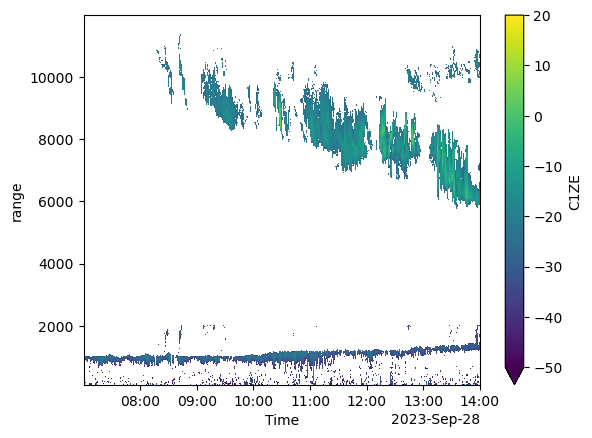

In [8]:
Ze_dBZ.plot(x="Time", y="range", vmin=-50, vmax=20, cmap="viridis")

DO SAME FOR KA

In [9]:
ka_files = sorted(glob.glob(str(base_path_ka / "*ZEN.LV1.nc")))
ds_ka = xr.open_mfdataset(ka_files)

In [10]:
ds_ka = ds_ka.assign_coords(Time=epoch + pd.to_timedelta(ds_ka["Time"].values, unit="s"))

C:\Users\geron\AppData\Local\Temp\ipykernel_28516\1792008399.py:1: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_ka = ds_ka.assign_coords(Time=epoch + pd.to_timedelta(ds_ka["Time"].values, unit="s"))


In [12]:
Ze_ka_dBZ = get_reflectivity(ds_ka)

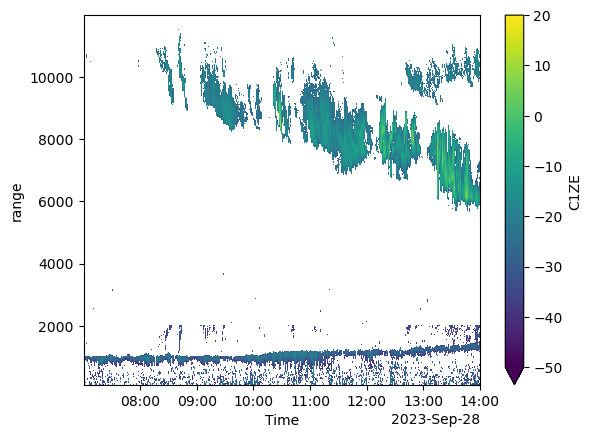

In [13]:
Ze_ka_dBZ.plot(x="Time", y="range", vmin=-50, vmax=20, cmap="viridis")